In [1]:
# Ipl Data Analysis 

In [2]:
# Importing Libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
# Loading Data

matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
# Data Cleaning 

In [7]:
# Cleaning 'matches' DataFrame

In [8]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [9]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [10]:
# Convert date column into datetime
matches['date'] = pd.to_datetime(
    matches['date'],
    dayfirst=True
)

C:\Users\Ranak\AppData\Local\Temp\ipykernel_8968\3698200299.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  matches['date'] = pd.to_datetime(


In [11]:
# Convert season column
matches['season'] = matches['date'].dt.year

In [12]:
matches.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [13]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [14]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [15]:
matches[matches['winner'].isnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [16]:
matches[matches['result_margin'].isnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
66,392190,2009,Cape Town,2009-04-23,League,YK Pathan,Newlands,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,NaN,151.0,20.0,Y,NaN,MR Benson,M Erasmus
130,419121,2010,Chennai,2010-03-21,League,J Theron,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,NaN,137.0,20.0,Y,NaN,K Hariharan,DJ Harper
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
328,598004,2013,Hyderabad,2013-04-07,League,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,NaN,131.0,20.0,Y,NaN,AK Chaudhary,S Ravi
342,598017,2013,Bangalore,2013-04-16,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,NaN,153.0,20.0,Y,NaN,M Erasmus,VA Kulkarni
416,729315,2014,Abu Dhabi,2014-04-29,League,JP Faulkner,Sheikh Zayed Stadium,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,NaN,153.0,20.0,Y,NaN,Aleem Dar,AK Chaudhary
475,829741,2015,Ahmedabad,2015-04-21,League,SE Marsh,"Sardar Patel Stadium, Motera",Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,tie,NaN,192.0,20.0,Y,NaN,M Erasmus,S Ravi
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
610,1082625,2017,Rajkot,2017-04-29,League,KH Pandya,Saurashtra Cricket Association Stadium,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,NaN,154.0,20.0,Y,NaN,AK Chaudhary,CB Gaffaney


In [17]:
matches['super_over'].unique()

array(['N', 'Y'], dtype=object)

In [18]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [19]:
matches['method'].unique()

array([nan, 'D/L'], dtype=object)

In [20]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [21]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [22]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int32         
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [23]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [24]:
matches[matches['result_margin'].isnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
66,392190,2009,Cape Town,2009-04-23,League,YK Pathan,Newlands,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,NaN,151.0,20.0,Y,NaN,MR Benson,M Erasmus
130,419121,2010,Chennai,2010-03-21,League,J Theron,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,NaN,137.0,20.0,Y,NaN,K Hariharan,DJ Harper
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
328,598004,2013,Hyderabad,2013-04-07,League,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,NaN,131.0,20.0,Y,NaN,AK Chaudhary,S Ravi
342,598017,2013,Bangalore,2013-04-16,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,NaN,153.0,20.0,Y,NaN,M Erasmus,VA Kulkarni
416,729315,2014,Abu Dhabi,2014-04-29,League,JP Faulkner,Sheikh Zayed Stadium,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,NaN,153.0,20.0,Y,NaN,Aleem Dar,AK Chaudhary
475,829741,2015,Ahmedabad,2015-04-21,League,SE Marsh,"Sardar Patel Stadium, Motera",Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,tie,NaN,192.0,20.0,Y,NaN,M Erasmus,S Ravi
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
610,1082625,2017,Rajkot,2017-04-29,League,KH Pandya,Saurashtra Cricket Association Stadium,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,NaN,154.0,20.0,Y,NaN,AK Chaudhary,CB Gaffaney


In [25]:
matches.loc[
    matches['result'] == 'tie',
    'result_margin'
] = 0

In [26]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin         5
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [27]:
matches[matches['result_margin'].isnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [28]:
matches.loc[
    matches['target_runs'].isnull() & matches['target_overs'].isnull(),
    ['target_runs','target_overs']
] = -1

In [29]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin         5
target_runs           0
target_overs          0
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [30]:
matches[matches['result_margin'].isnull()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,-1.0,-1.0,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,-1.0,-1.0,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,-1.0,-1.0,N,NaN,AK Chaudhary,NA Patwardhan


In [31]:
matches.loc[matches['winner'].isnull(),'winner'] = 'no result'

In [32]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin         5
target_runs           0
target_overs          0
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [33]:
matches.loc[matches['result_margin'].isnull(),'result_margin'] = -1

In [34]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin         0
target_runs           0
target_overs          0
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [35]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [36]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int32         
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1095 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1095 non-null   float64       
 14  target_runs      1095 non-null   float64

In [37]:
# Type Casting the columns 

In [38]:
cols = ['result_margin','target_runs','target_overs']

matches[cols] = matches[cols].astype('int')
print('Type Casting Successful')

Type Casting Successful


In [39]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int32         
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1095 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1095 non-null   int64         
 14  target_runs      1095 non-null   int64  

In [40]:
# Cleaning "deliveries" DataFrame 

In [41]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [42]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [43]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [44]:
deliveries.nunique()

match_id            1095
inning                 6
batting_team          19
bowling_team          19
over                  20
ball                  11
batter               673
bowler               530
non_striker          663
batsman_runs           7
extra_runs             7
total_runs             8
extras_type            5
is_wicket              2
player_dismissed     629
dismissal_kind        10
fielder              607
dtype: int64

In [45]:
deliveries['batsman_runs'].unique()

array([0, 4, 6, 1, 2, 5, 3])

In [46]:
deliveries['extra_runs'].unique()

array([1, 0, 5, 4, 2, 3, 7])

In [47]:
deliveries['extras_type'].unique()

array(['legbyes', nan, 'wides', 'byes', 'noballs', 'penalty'],
      dtype=object)

In [48]:
deliveries['total_runs'].unique()

array([1, 0, 4, 6, 5, 2, 3, 7])

In [49]:
deliveries['inning'].unique()

array([1, 2, 3, 4, 5, 6])

In [50]:
deliveries['is_wicket'].unique()

array([0, 1])

In [51]:
# Loading SQL queries as Dataframe in pandas 

In [52]:
import mysql.connector as sql

conn = sql.connect(
        host = 'localhost',
        user = 'root',
        password = 'ranak',
        database = 'Ipl_Analysis'
        )

print('Connected ....')

Connected ....


In [53]:
# Sql Queries 

query = """

WITH batsman_records AS
(
    SELECT
        batter AS Batsman,
        SUM(batsman_runs) AS Runs,
        COUNT(
            CASE
                WHEN extras_type != 'wides' OR extras_type IS NULL
                THEN ball
            END
        ) AS Balls_Faced,
        SUM(
            CASE
                WHEN batsman_runs = 4 THEN 1
                ELSE 0
            END
        ) AS Fours,
        SUM(
            CASE
                WHEN batsman_runs = 6 THEN 1
                ELSE 0
            END
        ) AS Sixes
    FROM deliveries
    GROUP BY batter
),
match_records as 
(
	select 
		match_id,
        batter,
        sum(batsman_runs) as Inning_Runs
        from deliveries
        group by match_id,batter
),
milestones as 
(
	select 
		batter,
        count(
			case 
				when Inning_Runs >= 50 and Inning_Runs <= 99 then 1
			end
		) as Fifties,
        count(
			case 
				when Inning_Runs >= 100 then 1
			end
		) as Hundreds
	from match_records
	group by batter
)

SELECT
    bs.Batsman,
    bs.Runs,
    bs.Balls_Faced,
    bs.Fours,
    bs.Sixes,
    round(bs.Runs / bs.Balls_Faced * 100,2) as Strike_Rate,
    m.Fifties,
    m.Hundreds
FROM batsman_records as bs
inner join milestones as m
on bs.Batsman = m.batter
ORDER BY Runs DESC;


"""

In [54]:
batsman_records = pd.read_sql(query,conn)
print('Data Loaded')

C:\Users\Ranak\AppData\Local\Temp\ipykernel_8968\25329329.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  batsman_records = pd.read_sql(query,conn)


Data Loaded


In [55]:
batsman_records

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014.0,6069,708.0,273.0,132.05,56,8
1,S Dhawan,6769.0,5326,768.0,153.0,127.09,51,2
2,RG Sharma,6630.0,5057,599.0,281.0,131.11,43,2
3,DA Warner,6567.0,4702,663.0,236.0,139.66,62,4
4,SK Raina,5536.0,4046,506.0,204.0,136.83,39,1
...,...,...,...,...,...,...,...,...
668,Yash Dayal,0.0,1,0.0,0.0,0.00,0,0
669,RP Meredith,0.0,3,0.0,0.0,0.00,0,0
670,R Sanjay Yadav,0.0,2,0.0,0.0,0.00,0,0
671,KM Asif,0.0,2,0.0,0.0,0.00,0,0


In [56]:
# Loading Bowler Stats Query 

query1 = """

# Bowling Stats 

with bowling_stats as
(
	select
		bowler as Bowler,
        count(
			case 
            when extras_type != 'wides' or extras_type is null then 1 
            end 
        ) as Ball_Bowled,
        sum(
        case 
        when dismissal_kind not in ('run out','retired hurt','obstructing the field','retired out','') and is_wicket = 1 then 1 
        else 0
        end ) as Wicket_Taken, 
		sum(
			batsman_runs +
			case
				when extras_type in ('wides','noballs')
				then extra_runs
				else 0
			end
		) as Run_Conceded,
        SUM(
			CASE
				WHEN total_runs = 0 THEN 1
				ELSE 0
			END
		) AS Dot_Balls
	from deliveries
    group by bowler

)

select 
	Bowler,
    Ball_Bowled,
    Wicket_Taken,
    round(Ball_Bowled / Wicket_Taken,2) as Strike_Rate,
    Run_Conceded,
	round(Run_Conceded / Wicket_Taken, 2) as Bowling_Average,
	round(Run_Conceded / (Ball_Bowled / 6), 2) as Economy,
    Dot_Balls
from bowling_stats;


"""

In [57]:
# Loading record in "bowler_records" dataframe 
bowler_records = pd.read_sql(query1,conn)
print('Data Loaded Successfully')

C:\Users\Ranak\AppData\Local\Temp\ipykernel_8968\2821989655.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bowler_records = pd.read_sql(query1,conn)


Data Loaded Successfully


In [58]:
bowler_records.head()

,Bowler,Ball_Bowled,Wicket_Taken,Strike_Rate,Run_Conceded,Bowling_Average,Economy,Dot_Balls
0,P Kumar,2525,90.0,28.06,3251.0,36.12,7.73,1075.0
1,Z Khan,2202,102.0,21.59,2782.0,27.27,7.58,873.0
2,AA Noffke,24,1.0,24.00,40.0,40.00,10.00,6.0
3,JH Kallis,1751,65.0,26.94,2293.0,35.28,7.86,601.0
4,SB Joshi,55,1.0,55.00,82.0,82.00,8.95,18.0


In [59]:
batsman_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Batsman      673 non-null    object 
 1   Runs         673 non-null    float64
 2   Balls_Faced  673 non-null    int64  
 3   Fours        673 non-null    float64
 4   Sixes        673 non-null    float64
 5   Strike_Rate  673 non-null    float64
 6   Fifties      673 non-null    int64  
 7   Hundreds     673 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 42.2+ KB


In [60]:
cols = ['Runs','Fours','Sixes']
batsman_records[cols] = batsman_records[cols].astype('int')

print('Type Casted Sucessfully')

Type Casted Sucessfully


In [61]:
bowler_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Bowler           530 non-null    object 
 1   Ball_Bowled      530 non-null    int64  
 2   Wicket_Taken     530 non-null    float64
 3   Strike_Rate      451 non-null    float64
 4   Run_Conceded     530 non-null    float64
 5   Bowling_Average  451 non-null    float64
 6   Economy          530 non-null    float64
 7   Dot_Balls        530 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 33.3+ KB


In [62]:
cols = ['Wicket_Taken','Run_Conceded','Dot_Balls']
bowler_records[cols] = bowler_records[cols].astype('int')

print('Type Casted Sucessfully')

Type Casted Sucessfully


In [63]:
batsman_records.head()

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014,6069,708,273,132.05,56,8
1,S Dhawan,6769,5326,768,153,127.09,51,2
2,RG Sharma,6630,5057,599,281,131.11,43,2
3,DA Warner,6567,4702,663,236,139.66,62,4
4,SK Raina,5536,4046,506,204,136.83,39,1


In [64]:
bowler_records.head()

,Bowler,Ball_Bowled,Wicket_Taken,Strike_Rate,Run_Conceded,Bowling_Average,Economy,Dot_Balls
0,P Kumar,2525,90,28.06,3251,36.12,7.73,1075
1,Z Khan,2202,102,21.59,2782,27.27,7.58,873
2,AA Noffke,24,1,24.00,40,40.00,10.00,6
3,JH Kallis,1751,65,26.94,2293,35.28,7.86,601
4,SB Joshi,55,1,55.00,82,82.00,8.95,18


# EDA Analysis 

In [65]:
# Some Teams Names were changed throughout the year's so we need to change ans set the latest ones for them 

matches['winner'] = matches['winner'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants'
})

In [66]:
team_wins = matches[matches['winner'] != 'no result'].groupby(['winner']).agg(Matches_Won = ('winner','count')).sort_values(by = ['Matches_Won'],ascending = [False])
team_wins

,Matches_Won
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bengaluru,123
Delhi Capitals,115
Punjab Kings,112
Rajasthan Royals,112
Sunrisers Hyderabad,88
Deccan Chargers,29


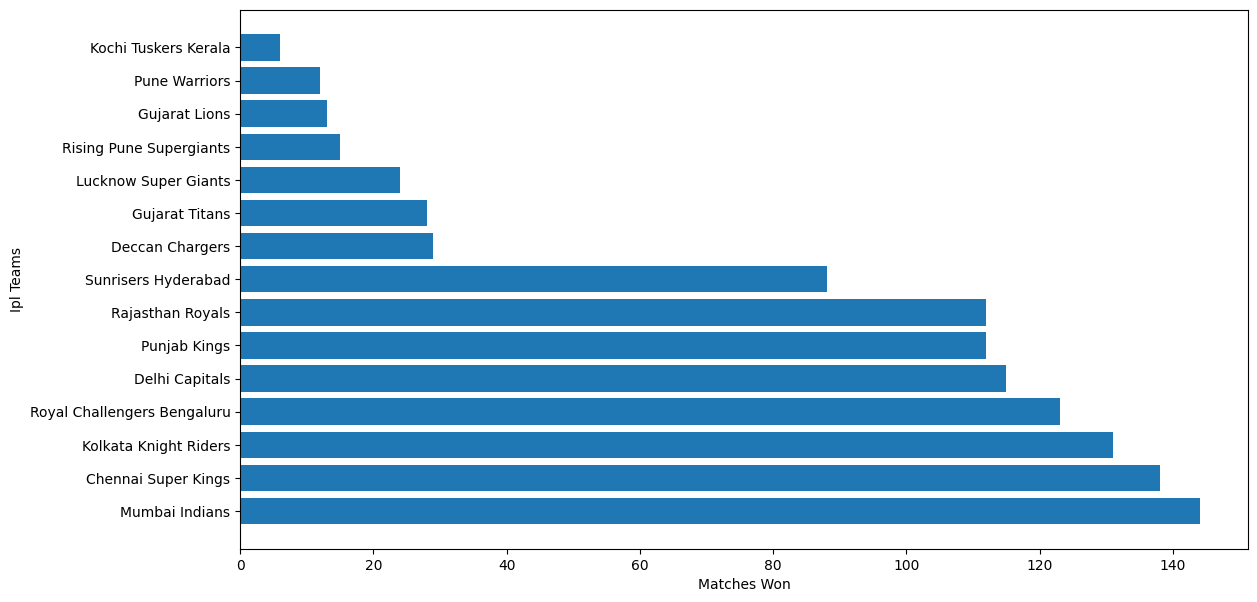

In [67]:
# Using Bar plot for visulaization 

plt.figure(figsize = (13,7))
plt.barh(team_wins.index,team_wins['Matches_Won'])
plt.ylabel('Ipl Teams')
plt.xlabel('Matches Won')
plt.show()


In [68]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [69]:
matches['toss_decision'].unique()

array(['field', 'bat'], dtype=object)

In [70]:
toss_decisions = matches.groupby(['toss_decision']).agg(Decision_Count = ('toss_decision','count'))
toss_decisions

,Decision_Count
toss_decision,
bat,391
field,704


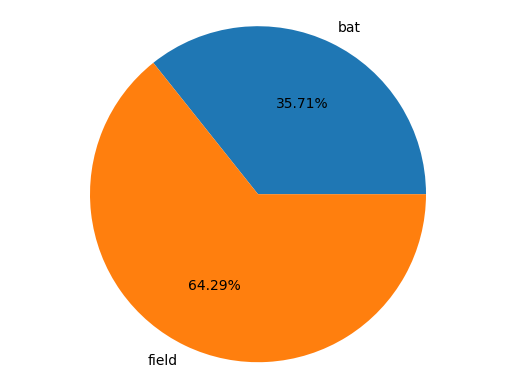

In [71]:
# Using pie Chart to visualize the stats 

plt.pie(toss_decisions['Decision_Count'],labels = toss_decisions.index,autopct = '%1.2f%%')
plt.axis('equal')
plt.show()

In [72]:
matches['match_type'].unique()

array(['League', 'Semi Final', 'Final', '3rd Place Play-Off',
       'Qualifier 1', 'Elimination Final', 'Qualifier 2', 'Eliminator'],
      dtype=object)

In [73]:
finalists = matches[matches['match_type'] == 'Final']
finalists.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
57,336040,2008,Mumbai,2008-06-01,Final,YK Pathan,Dr DY Patil Sports Academy,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3,164,20,N,NaN,BF Bowden,RE Koertzen
114,392239,2009,Johannesburg,2009-05-24,Final,A Kumble,New Wanderers Stadium,Royal Challengers Bangalore,Deccan Chargers,Royal Challengers Bangalore,field,Deccan Chargers,runs,6,144,20,N,NaN,RE Koertzen,SJA Taufel
174,419165,2010,Mumbai,2010-04-25,Final,SK Raina,Dr DY Patil Sports Academy,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,Chennai Super Kings,runs,22,169,20,N,NaN,RE Koertzen,SJA Taufel
247,501271,2011,Chennai,2011-05-28,Final,M Vijay,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings,bat,Chennai Super Kings,runs,58,206,20,N,NaN,Asad Rauf,SJA Taufel
321,548381,2012,Chennai,2012-05-27,Final,MS Bisla,"MA Chidambaram Stadium, Chepauk",Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,wickets,5,191,20,N,NaN,BF Bowden,SJA Taufel


In [74]:
Final_winners = finalists.groupby(['winner']).agg(Trophies = ('winner','count')).sort_values(by = ['Trophies'],ascending = [False])
Final_winners

,Trophies
winner,
Chennai Super Kings,5
Mumbai Indians,5
Kolkata Knight Riders,3
Gujarat Titans,1
Deccan Chargers,1
Rajasthan Royals,1
Sunrisers Hyderabad,1


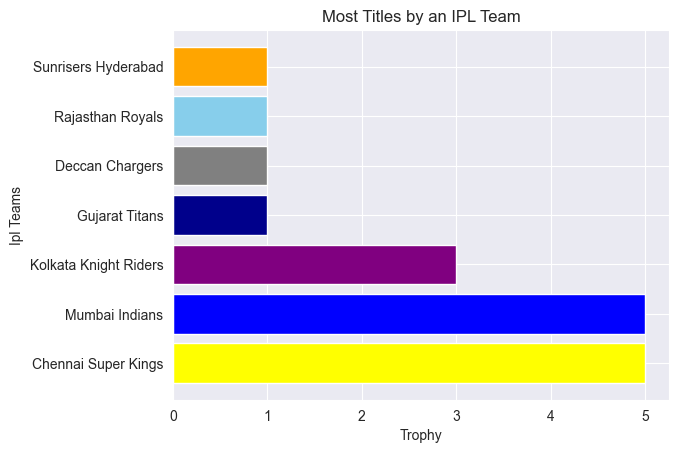

In [172]:
# Bar Plot 

plt.barh(Final_winners.index,Final_winners['Trophies'],color = ['yellow','blue','purple','darkblue','gray','skyblue','orange'])
plt.title('Most Titles by an IPL Team')
plt.xlabel('Trophy')
plt.ylabel('Ipl Teams')
plt.show()

In [76]:
super_over_stats = matches[matches['super_over'] == 'Y']
super_over_stats

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
66,392190,2009,Cape Town,2009-04-23,League,YK Pathan,Newlands,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,0,151,20,Y,NaN,MR Benson,M Erasmus
130,419121,2010,Chennai,2010-03-21,League,J Theron,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Punjab Kings,tie,0,137,20,Y,NaN,K Hariharan,DJ Harper
328,598004,2013,Hyderabad,2013-04-07,League,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,0,131,20,Y,NaN,AK Chaudhary,S Ravi
342,598017,2013,Bangalore,2013-04-16,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bengaluru,tie,0,153,20,Y,NaN,M Erasmus,VA Kulkarni
416,729315,2014,Abu Dhabi,2014-04-29,League,JP Faulkner,Sheikh Zayed Stadium,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,0,153,20,Y,NaN,Aleem Dar,AK Chaudhary
475,829741,2015,Ahmedabad,2015-04-21,League,SE Marsh,"Sardar Patel Stadium, Motera",Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Punjab Kings,tie,0,192,20,Y,NaN,M Erasmus,S Ravi
610,1082625,2017,Rajkot,2017-04-29,League,KH Pandya,Saurashtra Cricket Association Stadium,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,0,154,20,Y,NaN,AK Chaudhary,CB Gaffaney
705,1175365,2019,Delhi,2019-03-30,League,PP Shaw,Arun Jaitley Stadium,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals,field,Delhi Capitals,tie,0,186,20,Y,NaN,AY Dandekar,Nitin Menon
746,1178426,2019,Mumbai,2019-05-02,League,JJ Bumrah,Wankhede Stadium,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,Mumbai Indians,tie,0,163,20,Y,NaN,CK Nandan,S Ravi
757,1216493,2020,NaN,2020-09-20,League,MP Stoinis,Dubai International Cricket Stadium,Delhi Capitals,Kings XI Punjab,Kings XI Punjab,field,Delhi Capitals,tie,0,158,20,Y,NaN,AK Chaudhary,Nitin Menon


In [77]:
matches[matches['super_over'] == 'Y']['super_over'].count()

np.int64(14)

In [78]:
super_over_winner = super_over_stats.groupby(['winner']).agg(count = ('winner','count'))
super_over_winner

,count
winner,
Delhi Capitals,3
Kolkata Knight Riders,1
Mumbai Indians,2
Punjab Kings,3
Rajasthan Royals,2
Royal Challengers Bengaluru,2
Sunrisers Hyderabad,1


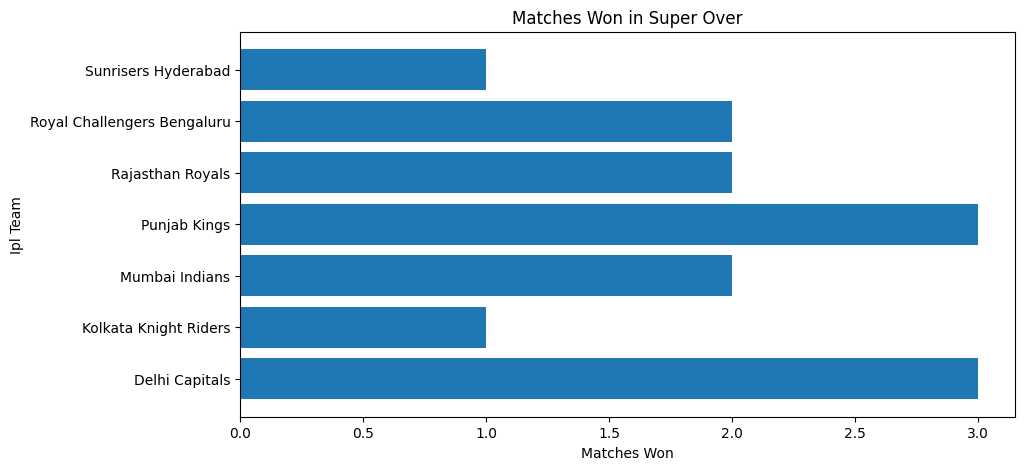

In [79]:
# bar plot 

plt.figure(figsize = (10,5))
plt.barh(super_over_winner.index,super_over_winner['count'])
plt.xlabel('Matches Won')
plt.ylabel('Ipl Team')
plt.title('Matches Won in Super Over')
plt.show()

In [80]:
top_run_getter = batsman_records.head(20)
top_run_getter

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014,6069,708,273,132.05,56,8
1,S Dhawan,6769,5326,768,153,127.09,51,2
2,RG Sharma,6630,5057,599,281,131.11,43,2
3,DA Warner,6567,4702,663,236,139.66,62,4
4,SK Raina,5536,4046,506,204,136.83,39,1
5,MS Dhoni,5243,3812,363,252,137.54,24,0
6,AB de Villiers,5181,3411,414,253,151.89,41,3
7,CH Gayle,4997,3346,408,359,149.34,32,6
8,RV Uthappa,4954,3801,481,182,130.33,27,0
9,KD Karthik,4843,3580,466,161,135.28,22,0


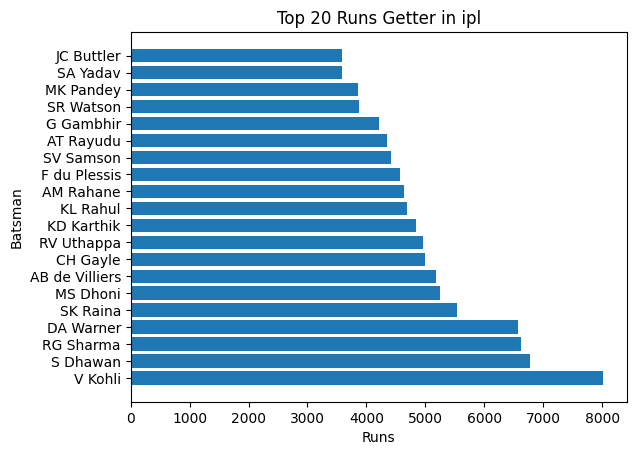

In [81]:
# Bar plot 

plt.barh(top_run_getter['Batsman'],top_run_getter['Runs'])
plt.title('Top 20 Runs Getter in ipl')
plt.xlabel('Runs')
plt.ylabel('Batsman')
plt.show()

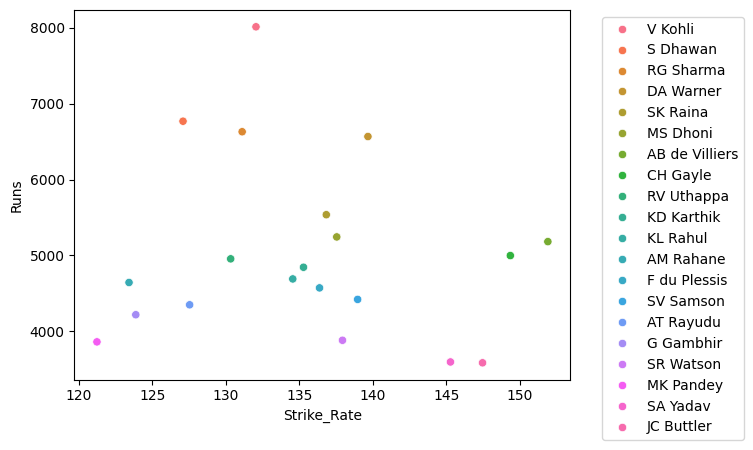

In [82]:
# Strike Rate v/s Runs 

sns.scatterplot(data = top_run_getter, x = 'Strike_Rate',y = 'Runs',hue = 'Batsman')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [83]:
top_wicket_taker = bowler_records.sort_values(by = ['Wicket_Taken'],ascending = [False]).head(20)
top_wicket_taker

,Bowler,Ball_Bowled,Wicket_Taken,Strike_Rate,Run_Conceded,Bowling_Average,Economy,Dot_Balls
268,YS Chahal,3530,205,17.22,4602,22.45,7.82,1194
16,PP Chawla,3852,192,20.06,5108,26.60,7.96,1325
55,DJ Bravo,3129,183,17.10,4360,23.83,8.36,998
211,B Kumar,3922,181,21.67,4929,27.23,7.54,1632
231,SP Narine,4085,180,22.69,4582,25.46,6.73,1569
145,R Ashwin,4528,180,25.16,5369,29.83,7.11,1552
87,A Mishra,3392,174,19.49,4145,23.82,7.33,1185
100,SL Malinga,2846,170,16.74,3364,19.79,7.09,1144
251,JJ Bumrah,3108,168,18.50,3743,22.28,7.23,1228
93,RA Jadeja,3834,160,23.96,4864,30.40,7.61,1216


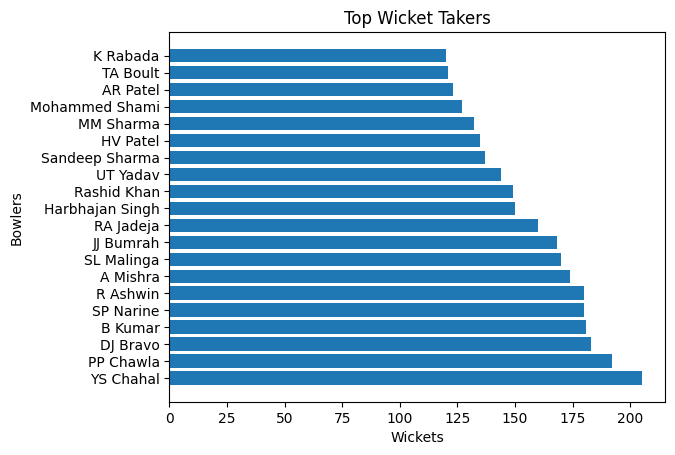

In [84]:
# bar plot 

plt.barh(top_wicket_taker['Bowler'],top_wicket_taker['Wicket_Taken'])
plt.title('Top Wicket Takers')
plt.xlabel('Wickets')
plt.ylabel('Bowlers')
plt.show()

In [85]:
# Economy v/s Wickets 

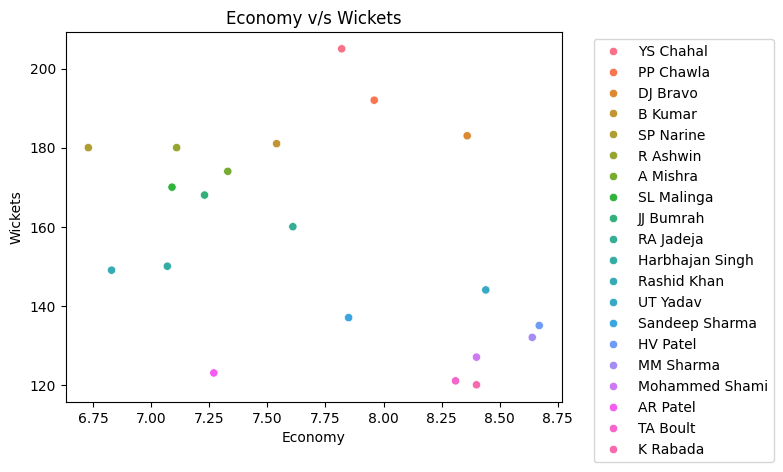

In [86]:
# Scatter plot 

sns.scatterplot(data = top_wicket_taker, x = "Economy", y = "Wicket_Taken",hue = 'Bowler')
plt.xlabel('Economy')
plt.ylabel('Wickets')
plt.title("Economy v/s Wickets")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
 
plt.show()

In [87]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [88]:
# Replacing same venue name to complete identical ones so we dont get seperate value for each stadium. 

value_mapping = {
    'Arun Jaitley Stadium':'Arun Jaitley Stadium, Delhi',
    'Brabourne Stadium':'Brabourne Stadium, Mumbai',
    'Dr DY Patil Sports Academy':'Dr DY Patil Sports Academy, Mumbai',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium':'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
    'Eden Gardens' : 'Eden Gardens, Kolkata',
    'Himachal Pradesh Cricket Association Stadium' : 'Himachal Pradesh Cricket Association Stadium, Dharamsala',
    'M Chinnaswamy Stadium' : 'M Chinnaswamy Stadium, Bengaluru',
    'M.Chinnaswamy Stadium' : 'M Chinnaswamy Stadium, Bengaluru',
    'MA Chidambaram Stadium' : 'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium, Chepauk, Chennai' : 'MA Chidambaram Stadium, Chepauk',
    'Maharashtra Cricket Association Stadium':'Maharashtra Cricket Association Stadium, Pune',
    'Punjab Cricket Association IS Bindra Stadium':'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
    'Punjab Cricket Association IS Bindra Stadium, Mohali' : 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
    'Punjab Cricket Association Stadium, Mohali' : 'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh',
    'Rajiv Gandhi International Stadium':'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
    'Rajiv Gandhi International Stadium, Uppal':'Rajiv Gandhi International Stadium, Uppal, Hyderabad',
    'Sawai Mansingh Stadium' : 'Sawai Mansingh Stadium, Jaipur',
    'Wankhede Stadium' : 'Wankhede Stadium, Mumbai'
}

In [89]:
matches['venue'] = matches['venue'].replace(value_mapping)

print('Values modified sucessfully')

Values modified sucessfully


In [90]:
venues = matches.groupby(['venue']).agg(Count = ('venue','count'))
venues

,Count
venue,
"Arun Jaitley Stadium, Delhi",30
Barabati Stadium,7
"Barsapara Cricket Stadium, Guwahati",3
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",14
"Brabourne Stadium, Mumbai",27
Buffalo Park,3
De Beers Diamond Oval,3
"Dr DY Patil Sports Academy, Mumbai",37
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",15


In [91]:
# top 10's 

venues.sort_values(by = 'Count',ascending = False).head(10)

,Count
venue,
"Wankhede Stadium, Mumbai",118
"M Chinnaswamy Stadium, Bengaluru",94
"Eden Gardens, Kolkata",93
"MA Chidambaram Stadium, Chepauk",85
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",77
"Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",61
Feroz Shah Kotla,60
"Sawai Mansingh Stadium, Jaipur",57
Dubai International Cricket Stadium,46


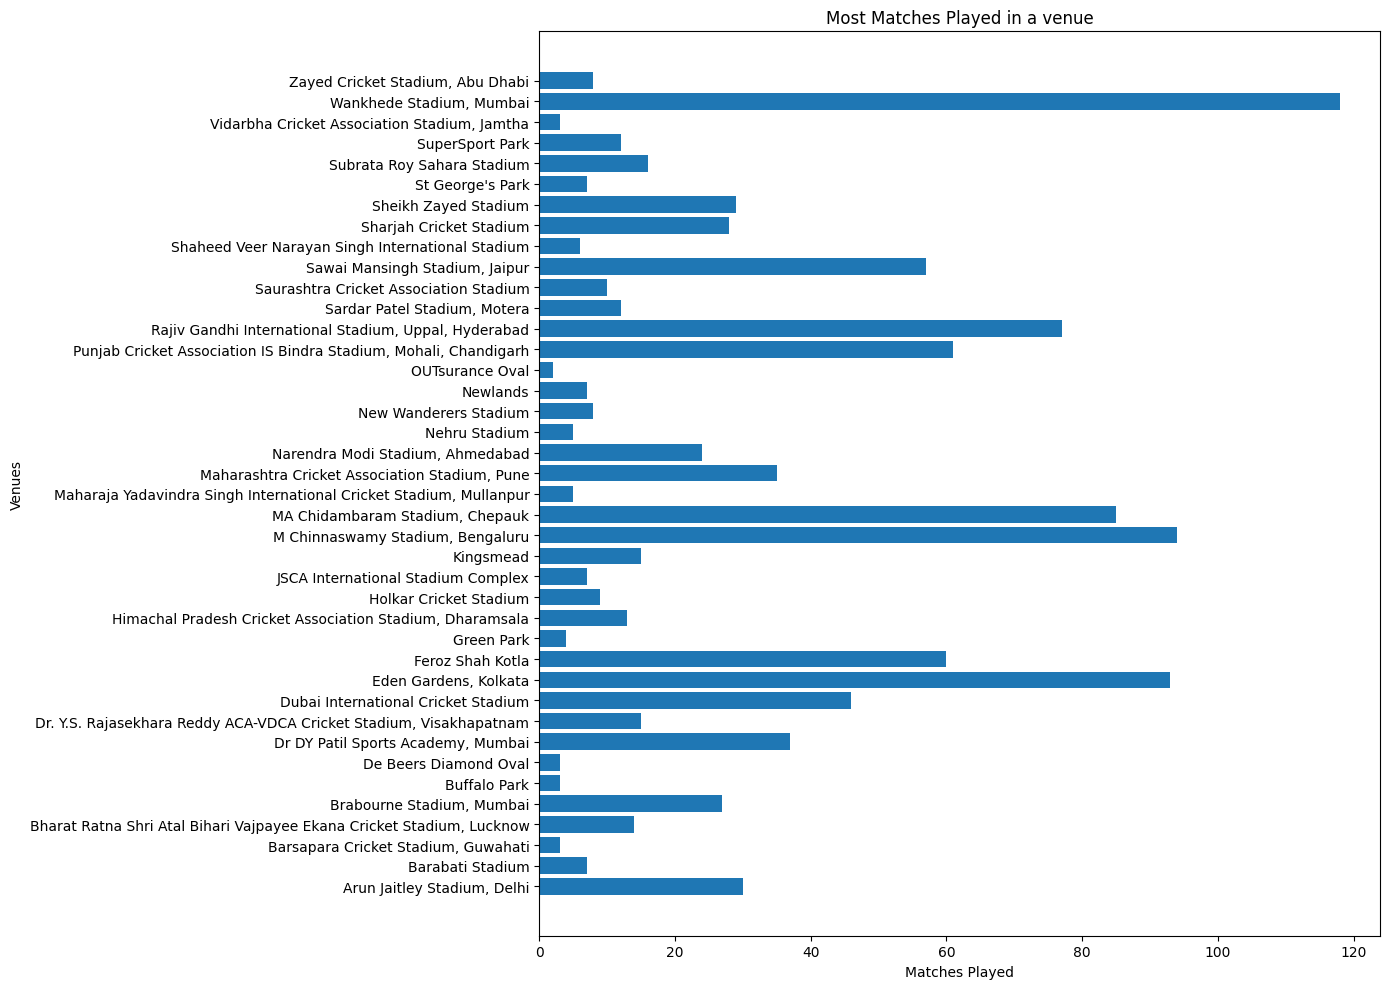

In [92]:
# Bar Plot 

plt.figure(figsize = (14,10))
plt.barh(venues.index,venues['Count'])
plt.xlabel('Matches Played')
plt.ylabel('Venues')
plt.title('Most Matches Played in a venue')
plt.tight_layout()
plt.show()

In [93]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association IS Bindra Stadium, ...",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [94]:
city_hoisted = matches.groupby(['city']).agg(Count = ('city','count'))
city_hoisted.sort_values(by = 'Count',ascending = False)

,Count
city,
Mumbai,173
Kolkata,93
Delhi,90
Chennai,85
Hyderabad,77
Bangalore,65
Chandigarh,61
Jaipur,57
Pune,51


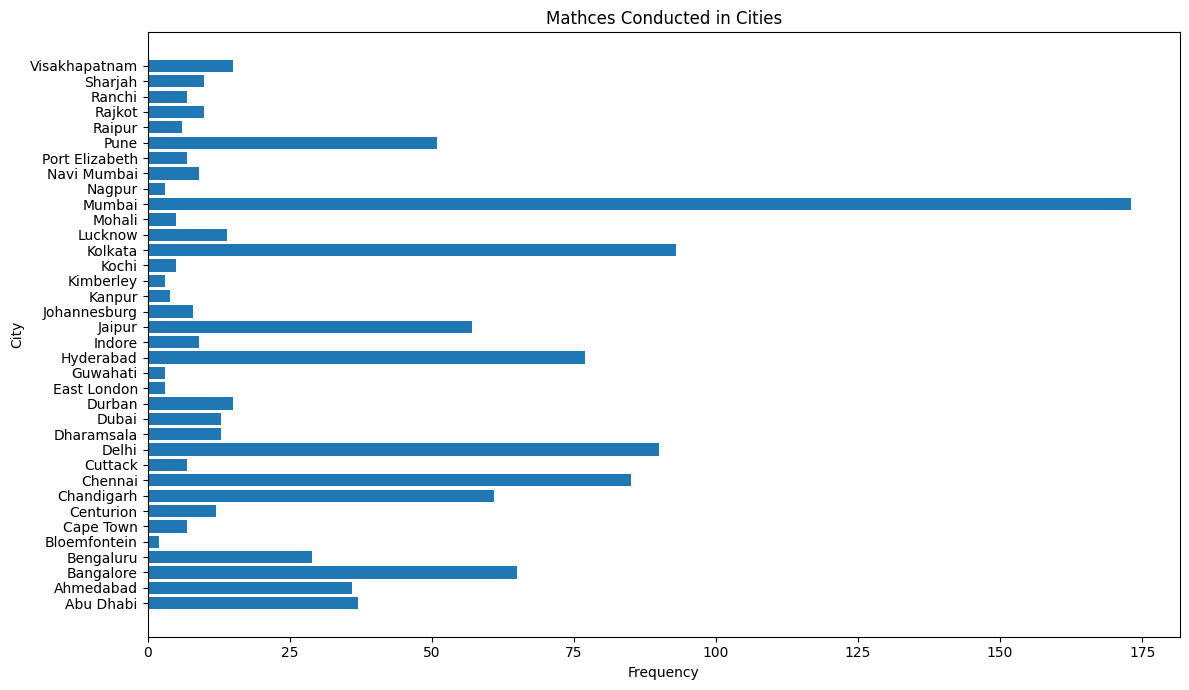

In [95]:
# Bar plot 

plt.figure(figsize = (12,7))
plt.barh(city_hoisted.index,city_hoisted['Count'])
plt.xlabel('Frequency')
plt.ylabel('City')
plt.title('Mathces Conducted in Cities')
plt.tight_layout()
plt.show()

In [96]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association IS Bindra Stadium, ...",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [97]:
POTM = matches.groupby(['player_of_match']).agg(Awards = ('player_of_match','count')).sort_values(by = 'Awards',ascending = False).query('Awards > 9')
POTM

,Awards
player_of_match,
AB de Villiers,25
CH Gayle,22
RG Sharma,19
DA Warner,18
V Kohli,18
MS Dhoni,17
SR Watson,16
YK Pathan,16
RA Jadeja,16


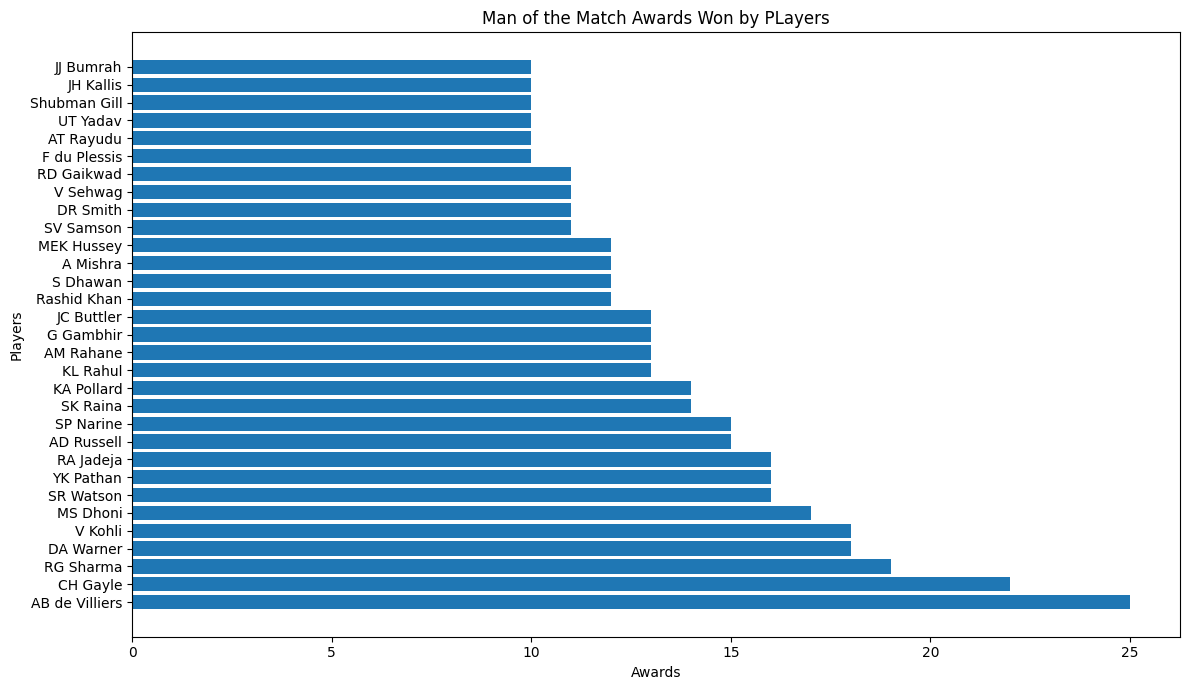

In [98]:
# Bar Plot 

plt.figure(figsize = (12,7))
plt.barh(POTM.index,POTM['Awards'])
plt.xlabel('Awards')
plt.ylabel('Players')
plt.title('Man of the Match Awards Won by PLayers')
plt.tight_layout()
plt.show()

In [99]:
_50s = batsman_records[batsman_records['Fifties'] > 20].sort_values(by = ['Fifties'],ascending = False)
_50s

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
3,DA Warner,6567,4702,663,236,139.66,62,4
0,V Kohli,8014,6069,708,273,132.05,56,8
1,S Dhawan,6769,5326,768,153,127.09,51,2
2,RG Sharma,6630,5057,599,281,131.11,43,2
6,AB de Villiers,5181,3411,414,253,151.89,41,3
4,SK Raina,5536,4046,506,204,136.83,39,1
10,KL Rahul,4689,3485,400,187,134.55,37,4
12,F du Plessis,4571,3352,422,166,136.37,37,0
15,G Gambhir,4217,3404,492,59,123.88,36,0
7,CH Gayle,4997,3346,408,359,149.34,32,6


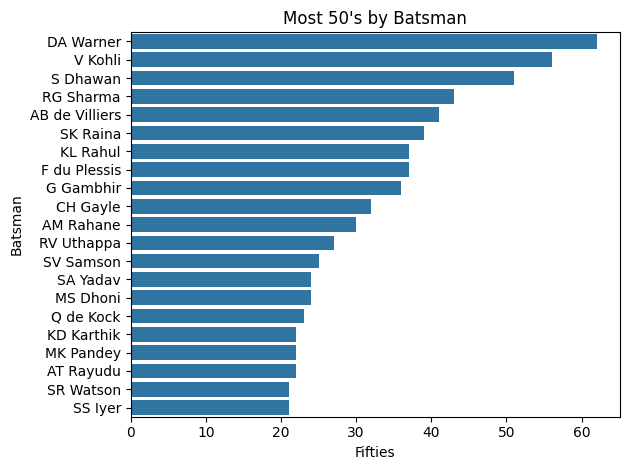

In [100]:
# Bar Plot

sns.barplot(data = _50s, x = 'Fifties', y = 'Batsman')
plt.title("Most 50's by Batsman")
plt.tight_layout()
plt.show()

In [101]:
_100s = batsman_records[batsman_records['Hundreds'] > 0].sort_values(by = ['Hundreds'],ascending = False)
_100s

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014,6069,708,273,132.05,56,8
19,JC Buttler,3583,2430,356,161,147.45,19,7
7,CH Gayle,4997,3346,408,359,149.34,32,6
3,DA Warner,6567,4702,663,236,139.66,62,4
16,SR Watson,3880,2813,377,190,137.93,21,4
23,Shubman Gill,3216,2370,310,95,135.70,20,4
10,KL Rahul,4689,3485,400,187,134.55,37,4
13,SV Samson,4419,3180,352,206,138.96,25,3
6,AB de Villiers,5181,3411,414,253,151.89,41,3
24,Q de Kock,3160,2355,316,123,134.18,23,2


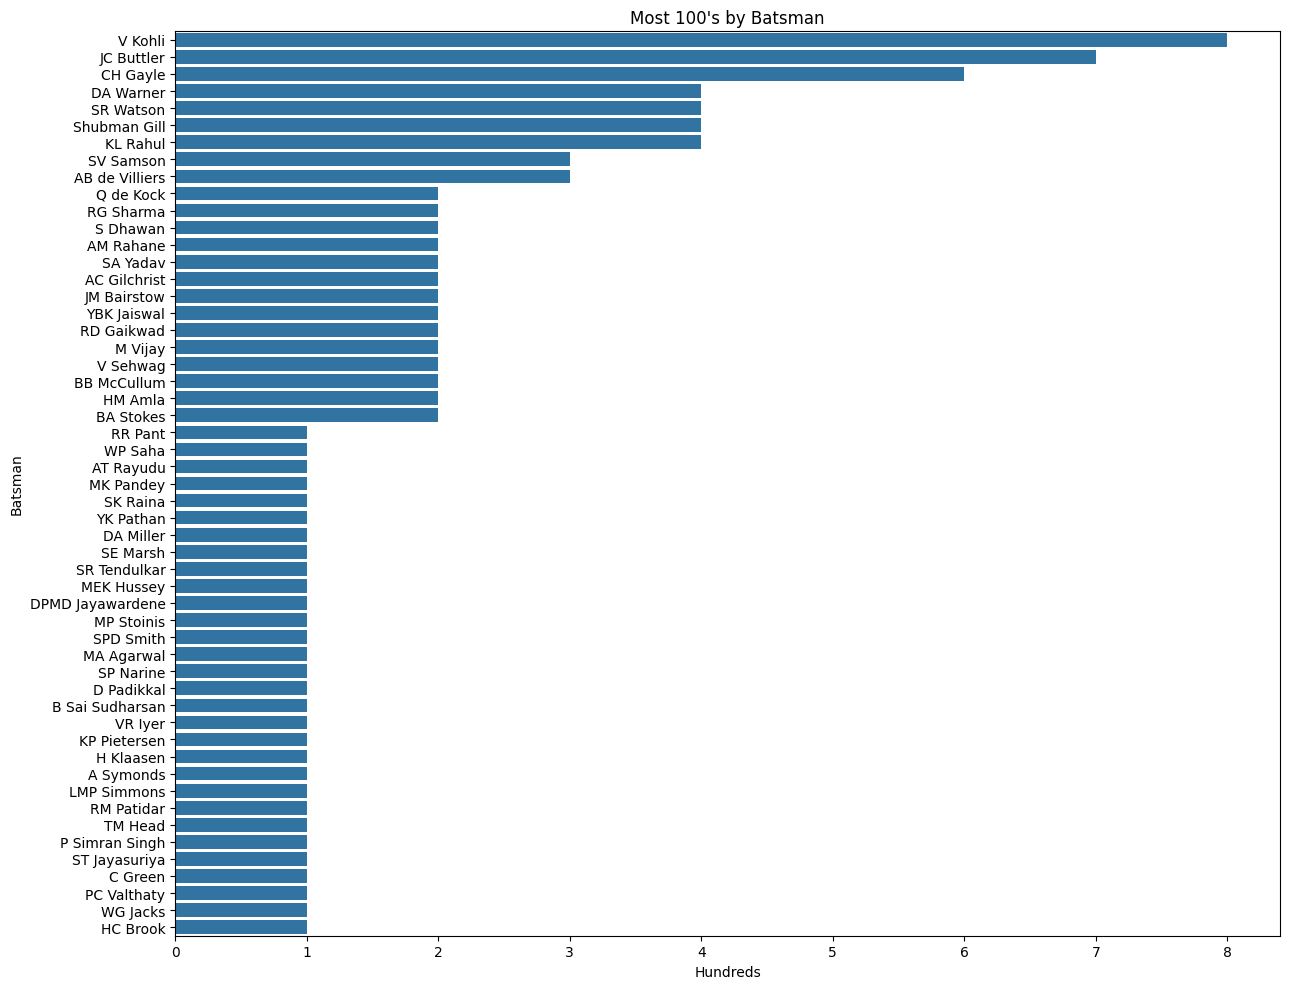

In [102]:
# Bar Plot

plt.figure(figsize = (13,10))
sns.barplot(data = _100s, x = 'Hundreds', y = 'Batsman')
plt.title("Most 100's by Batsman")
plt.tight_layout()
plt.show()

In [103]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association IS Bindra Stadium, ...",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [104]:
matches['toss_winner'] = matches['toss_winner'].str.strip()
matches['winner'] = matches['winner'].str.strip()

In [105]:
name_mapping = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

In [106]:
cols = ['team1','team2','toss_winner','winner']

matches[cols] = matches[cols].replace(name_mapping)

In [107]:
# Total Matches 
Total_Matches = len(matches['id'])

# Toss Won and match won by the teams 
TWMW = matches[matches['toss_winner'] == matches['winner']]

# Toss Won and match loss by the teams 
TWML = matches[matches['toss_winner'] != matches['winner']]


Total_Matches # Finding Total Matches played byfar in ipl

1095

In [108]:
TWMW

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association IS Bindra Stadium, ...",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
8,335990,2008,Hyderabad,2008-04-24,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3,215,20,N,NaN,Asad Rauf,MR Benson
10,335992,2008,Bangalore,2008-04-26,League,SR Watson,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,7,136,20,N,NaN,MR Benson,IL Howell
12,335994,2008,Mumbai,2008-04-27,League,AC Gilchrist,"Dr DY Patil Sports Academy, Mumbai",Mumbai Indians,Deccan Chargers,Deccan Chargers,field,Deccan Chargers,wickets,10,155,20,N,NaN,Asad Rauf,SL Shastri
14,335996,2008,Bangalore,2008-04-28,League,MS Dhoni,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,13,179,20,N,NaN,BR Doctrove,RB Tiffin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,1426287,2024,Chennai,2024-05-01,League,Harpreet Brar,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Punjab Kings,Punjab Kings,field,Punjab Kings,wickets,7,163,20,N,NaN,HAS Khalid,VK Sharma
1073,1426288,2024,Hyderabad,2024-05-02,League,B Kumar,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,1,202,20,N,NaN,AK Chaudhary,YC Barde
1075,1426290,2024,Bengaluru,2024-05-04,League,Mohammed Siraj,"M Chinnaswamy Stadium, Bengaluru",Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,wickets,4,148,20,N,NaN,A Totre,Vinod Seshan
1078,1426293,2024,Mumbai,2024-05-06,League,SA Yadav,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,7,174,20,N,NaN,Navdeep Singh,Tapan Sharma


In [109]:
TWML

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan
5,335987,2008,Jaipur,2008-04-21,League,SR Watson,"Sawai Mansingh Stadium, Jaipur",Rajasthan Royals,Punjab Kings,Punjab Kings,bat,Rajasthan Royals,wickets,6,167,20,N,NaN,Aleem Dar,RB Tiffin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,1426306,2024,Bengaluru,2024-05-18,League,F du Plessis,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,field,Royal Challengers Bengaluru,runs,27,219,20,N,NaN,A Totre,KN Ananthapadmanabhan
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4,215,20,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8,160,20,N,NaN,AK Chaudhary,R Pandit
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36,176,20,N,NaN,Nitin Menon,VK Sharma


In [110]:
# Finding Exact no of toss winner and match winner 
match_win = len(TWMW['id'])

# Finding Exact no of toss winner and match loser 
match_loss = len(TWML['id'])

print(f'Total Matches Won when Team won the Toss : {match_win}')

print(f'Total Matches Loss when Team won the Toss : {match_loss}')

print(f'Total Matches in Ipl Played : {Total_Matches}')

Total Matches Won when Team won the Toss : 554
Total Matches Loss when Team won the Toss : 541
Total Matches in Ipl Played : 1095


In [111]:
print(f"Percentage of Winning Match when team's won the Toss : {round(match_win/Total_Matches * 100,2)}%")
print(f"Percentage of Losing Match when team's won the Toss : {round(match_loss/Total_Matches * 100,2)}%")

Percentage of Winning Match when team's won the Toss : 50.59%
Percentage of Losing Match when team's won the Toss : 49.41%


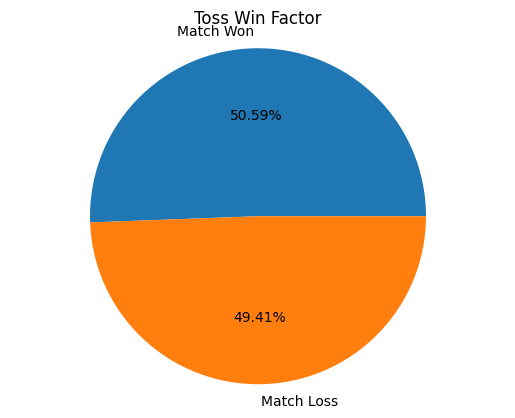

In [112]:
# pie Chart 

plt.pie([round(match_win/Total_Matches * 100,2),round(match_loss/Total_Matches * 100,2)],labels = ["Match Won","Match Loss"],autopct = "%1.2f%%")
plt.title('Toss Win Factor')
plt.axis('equal')
plt.show()

In [114]:
matches.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4,215,20,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8,160,20,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4,173,20,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36,176,20,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8,114,20,N,NaN,J Madanagopal,Nitin Menon


In [118]:
Avg_1st_Inn = matches.groupby(['season']).agg(First_Inn_Score = ('target_runs','mean'))

# Round off 1st inning score to 2 decimals 
Avg_1st_Inn['First_Inn_Score'] = Avg_1st_Inn['First_Inn_Score'].round(2)

Avg_1st_Inn

,First_Inn_Score
season,
2008,159.78
2009,148.81
2010,165.78
2011,151.92
2012,158.54
2013,156.89
2014,162.38
2015,161.90
2016,160.78


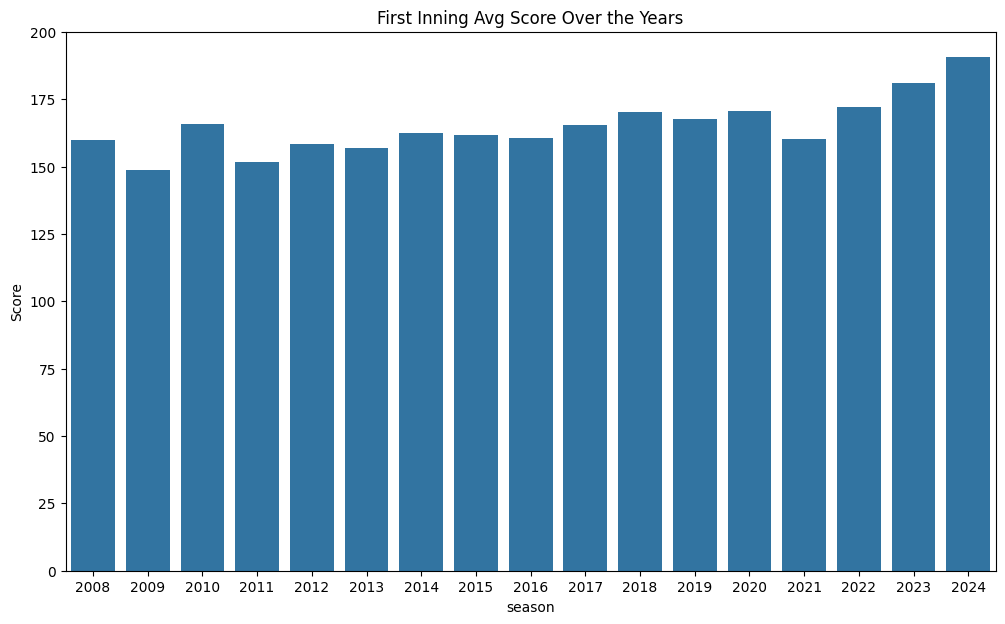

In [125]:
# Barplot

plt.figure(figsize = (12,7))
sns.barplot(data = Avg_1st_Inn,x = Avg_1st_Inn.index,y = 'First_Inn_Score')
plt.ylabel('Score')
plt.title('First Inning Avg Score Over the Years')
plt.show()

In [127]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140,223,20,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association IS Bindra Stadium, ...",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NaN,BF Bowden,K Hariharan


In [130]:
avg_score = matches.groupby('venue').agg(First_Inn_Score = ('target_runs','mean'))
avg_score['First_Inn_Score'] = avg_score['First_Inn_Score'].round(2)
avg_score

,First_Inn_Score
venue,
"Arun Jaitley Stadium, Delhi",184.17
Barabati Stadium,168.71
"Barsapara Cricket Stadium, Guwahati",181.00
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",157.36
"Brabourne Stadium, Mumbai",179.52
Buffalo Park,148.33
De Beers Diamond Oval,159.00
"Dr DY Patil Sports Academy, Mumbai",160.65
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",160.13


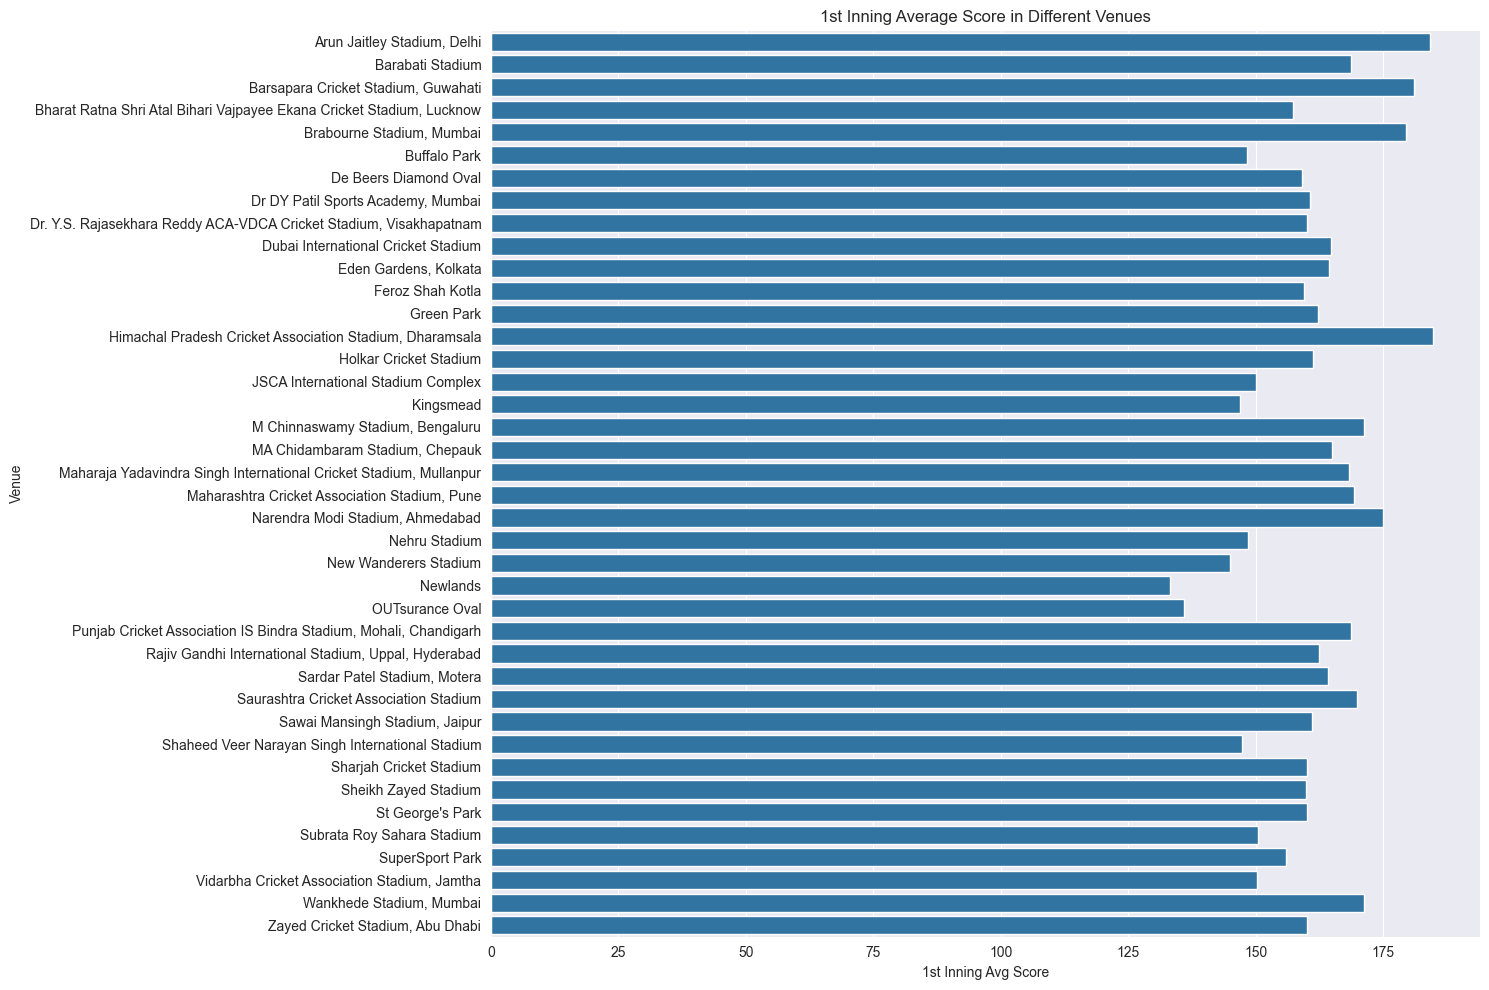

In [146]:
# barplot

plt.figure(figsize = (15,10))
sns.set_style("darkgrid")
sns.barplot(data = avg_score, y = avg_score.index , x = 'First_Inn_Score')
plt.title('1st Inning Average Score in Different Venues')
plt.xlabel('1st Inning Avg Score')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [148]:
balls_faced = batsman_records.sort_values(by = 'Balls_Faced',ascending = False).head(25)
balls_faced

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014,6069,708,273,132.05,56,8
1,S Dhawan,6769,5326,768,153,127.09,51,2
2,RG Sharma,6630,5057,599,281,131.11,43,2
3,DA Warner,6567,4702,663,236,139.66,62,4
4,SK Raina,5536,4046,506,204,136.83,39,1
5,MS Dhoni,5243,3812,363,252,137.54,24,0
8,RV Uthappa,4954,3801,481,182,130.33,27,0
11,AM Rahane,4642,3761,479,103,123.42,30,2
9,KD Karthik,4843,3580,466,161,135.28,22,0
10,KL Rahul,4689,3485,400,187,134.55,37,4


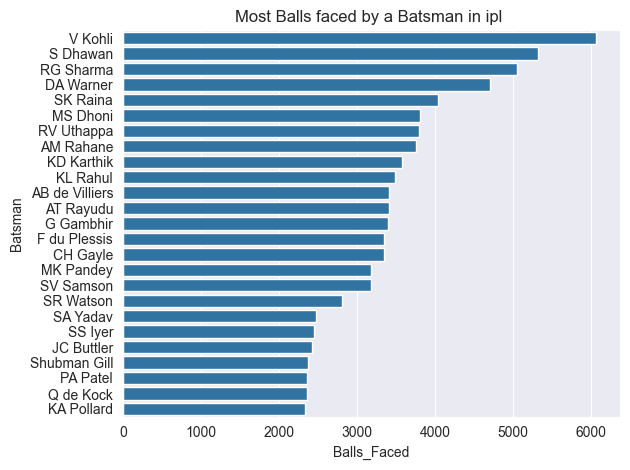

In [153]:
# Barplot 

sns.barplot(data = balls_faced, x = 'Balls_Faced' , y = 'Batsman')
plt.title('Most Balls faced by a Batsman in ipl ')
plt.tight_layout()
plt.show()

In [155]:
batsman_records.head()

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds
0,V Kohli,8014,6069,708,273,132.05,56,8
1,S Dhawan,6769,5326,768,153,127.09,51,2
2,RG Sharma,6630,5057,599,281,131.11,43,2
3,DA Warner,6567,4702,663,236,139.66,62,4
4,SK Raina,5536,4046,506,204,136.83,39,1


In [160]:
batsman_records['Boundaries'] = batsman_records['Fours'] + batsman_records['Sixes']
boundary = batsman_records.sort_values(by = 'Boundaries',ascending = False).head(25)
boundary

,Batsman,Runs,Balls_Faced,Fours,Sixes,Strike_Rate,Fifties,Hundreds,Boundaries
0,V Kohli,8014,6069,708,273,132.05,56,8,981
1,S Dhawan,6769,5326,768,153,127.09,51,2,921
3,DA Warner,6567,4702,663,236,139.66,62,4,899
2,RG Sharma,6630,5057,599,281,131.11,43,2,880
7,CH Gayle,4997,3346,408,359,149.34,32,6,767
4,SK Raina,5536,4046,506,204,136.83,39,1,710
6,AB de Villiers,5181,3411,414,253,151.89,41,3,667
8,RV Uthappa,4954,3801,481,182,130.33,27,0,663
9,KD Karthik,4843,3580,466,161,135.28,22,0,627
5,MS Dhoni,5243,3812,363,252,137.54,24,0,615


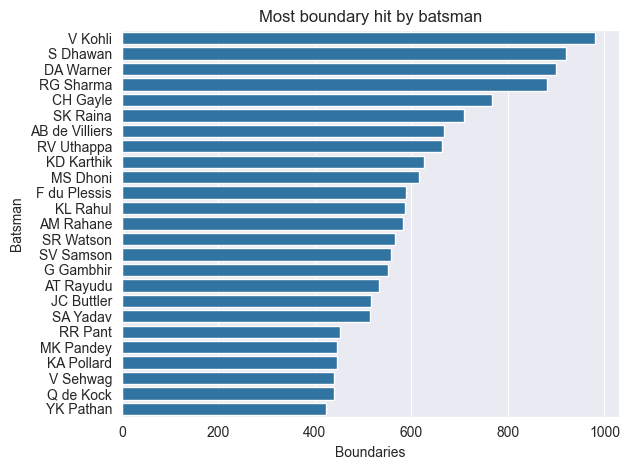

In [163]:
# barplot 

sns.barplot(data = boundary , x = 'Boundaries', y = 'Batsman')
plt.title('Most boundary hit by batsman')
plt.tight_layout()
plt.show()

In [169]:
economy = bowler_records.query('Ball_Bowled >= 2000 ').sort_values(by = ['Economy'],ascending = True).head(25)
economy

,Bowler,Ball_Bowled,Wicket_Taken,Strike_Rate,Run_Conceded,Bowling_Average,Economy,Dot_Balls
231,SP Narine,4085,180,22.69,4582,25.46,6.73,1569
334,Rashid Khan,2872,149,19.28,3267,21.93,6.83,1060
66,DW Steyn,2189,97,22.57,2523,26.01,6.92,1019
40,Harbhajan Singh,3420,150,22.80,4030,26.87,7.07,1263
100,SL Malinga,2846,170,16.74,3364,19.79,7.09,1144
145,R Ashwin,4528,180,25.16,5369,29.83,7.11,1552
251,JJ Bumrah,3108,168,18.50,3743,22.28,7.23,1228
281,AR Patel,3105,123,25.24,3764,30.60,7.27,1021
87,A Mishra,3392,174,19.49,4145,23.82,7.33,1185
319,KH Pandya,2125,76,27.96,2606,34.29,7.36,676


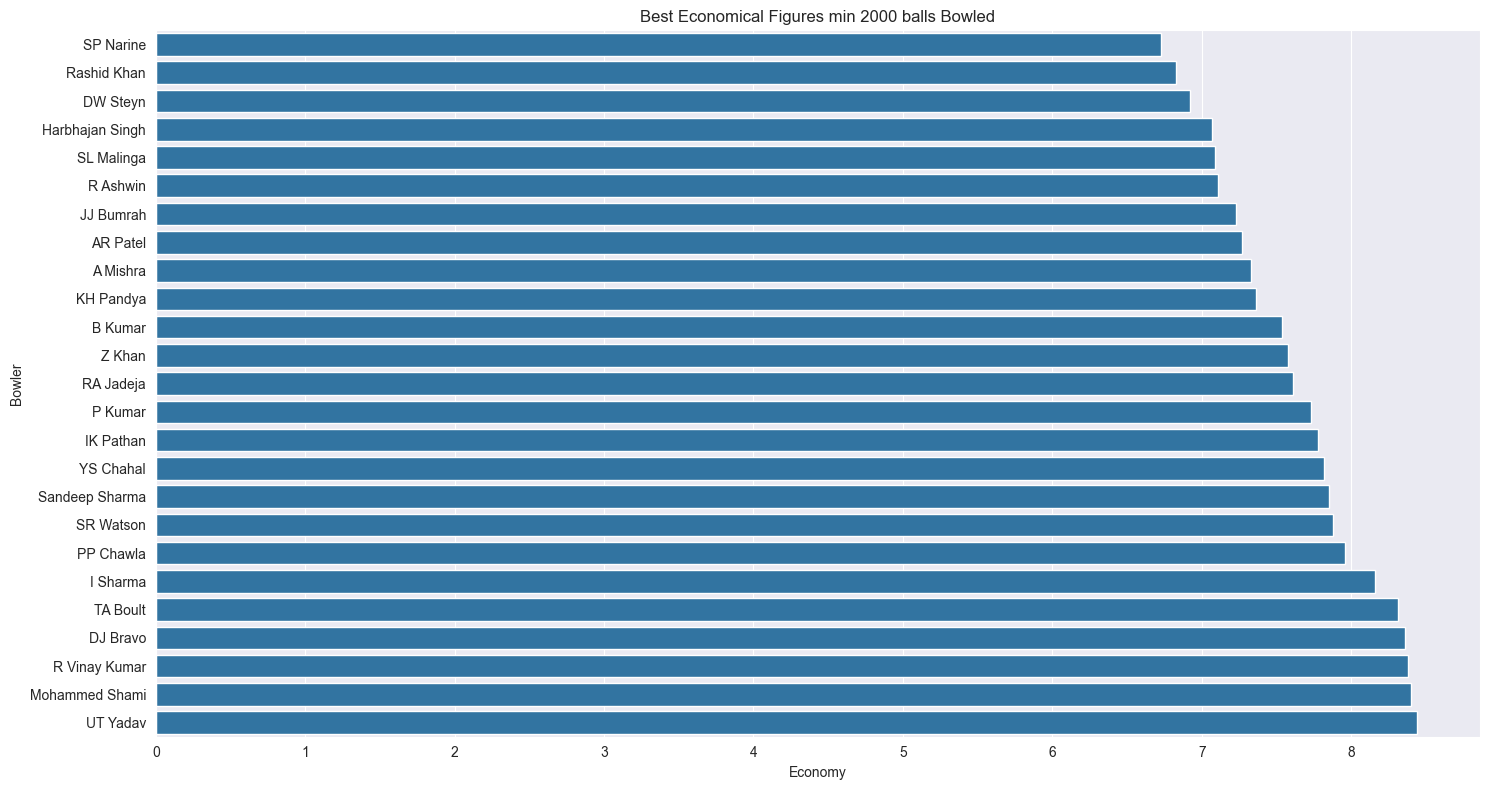

In [171]:
# Barplot

plt.figure(figsize = (15,8))
sns.barplot(data = economy,x = 'Economy' , y = 'Bowler')
plt.title('Best Economical Figures min 2000 balls Bowled')
plt.tight_layout()
plt.show()